# 03 — SpectralTransformer Training

Trains the masked Transformer encoder on the full 80,000 sample dataset.
Best val MSE: **0.002024** — 2.67× better than cubic spline baseline.

Runtime: T4 GPU (~32 epochs, ~17 minutes)

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import os, sys

REPO = "https://github.com/Arjun11x/spectral-bridge.git"
if not os.path.exists('/content/spectral-bridge'):
    !git clone {REPO}
else:
    !cd /content/spectral-bridge && git pull

sys.path.insert(0, '/content/spectral-bridge')
!pip install -q tqdm

TRAIN_CSV = "/content/drive/MyDrive/spectral-bridge/data/spectral_graffiti.csv"
TEST_CSV  = "/content/drive/MyDrive/spectral-bridge/data/test_features_spectral.csv"

assert os.path.exists(TRAIN_CSV), f"Training CSV not found at {TRAIN_CSV}"
assert os.path.exists(TEST_CSV),  f"Test CSV not found at {TEST_CSV}"

print("=" * 50)
print("Setup complete!")
print(f"Train CSV : {TRAIN_CSV}")
print(f"Test CSV  : {TEST_CSV}")
print("=" * 50)

Mounted at /content/drive
Cloning into 'spectral-bridge'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 55 (delta 24), reused 40 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 933.44 KiB | 32.19 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Setup complete!
Train CSV : /content/drive/MyDrive/spectral-bridge/data/spectral_graffiti.csv
Test CSV  : /content/drive/MyDrive/spectral-bridge/data/test_features_spectral.csv


In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src import config
from src.dataset import get_dataloaders
from src.model import SpectralTransformer, build_model, masked_mse_loss
from src.train import train
from src.evaluate import evaluate
from src.utils import set_seed, get_device, ensure_dirs, save_figure

print("All imports successful.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All imports successful.
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [3]:
# ── Cell 3: Config and device check ───────────────────────────────────────

set_seed(config.SEED)
device = get_device()
ensure_dirs()

print()
print(f"Model config:")
print(f"  d_model    : {config.D_MODEL}")
print(f"  n_heads    : {config.N_HEADS}")
print(f"  n_layers   : {config.N_LAYERS}")
print(f"  d_ff       : {config.D_FF}")
print(f"  dropout    : {config.DROPOUT}")
print()
print(f"Training config:")
print(f"  batch_size : {config.BATCH_SIZE}")
print(f"  epochs     : {config.NUM_EPOCHS}")
print(f"  lr         : {config.LEARNING_RATE}")
print(f"  patience   : {config.PATIENCE}")
print(f"  seed       : {config.SEED}")

Device: cuda — Tesla T4

Model config:
  d_model    : 64
  n_heads    : 4
  n_layers   : 3
  d_ff       : 256
  dropout    : 0.1

Training config:
  batch_size : 32
  epochs     : 20
  lr         : 0.001
  patience   : 5
  seed       : 42


In [4]:
# ── Cell 4: Load dataloaders ───────────────────────────────────────────────

print("Loading dataset...")
train_loader, val_loader = get_dataloaders(csv_path=TRAIN_CSV)

n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)

print(f"Train samples : {n_train:,}")
print(f"Val samples   : {n_val:,}")
print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")

Loading dataset...
Train samples : 64,000
Val samples   : 16,000
Train batches : 2,000
Val batches   : 500


In [5]:
# ── Cell 5: Build model ────────────────────────────────────────────────────

model = build_model().to(device)

p = model.parameter_count()
print(model)
print()
print(f"Total params     : {p['total']:,}")
print(f"Trainable params : {p['trainable']:,}")
print()
print(f"Input shape  : [batch, {config.SEQ_LEN}, {config.FEATURE_DIM}]")
print(f"Output shape : [batch, {config.SEQ_LEN}]")

SpectralTransformer(d_model=64, n_heads=4, n_layers=3, d_ff=256, dropout=0.1, params=156,609)

Total params     : 156,609
Trainable params : 156,609

Input shape  : [batch, 100, 2]
Output shape : [batch, 100]


Device: cuda — Tesla T4
No checkpoint found — starting fresh...
SpectralTransformer(d_model=64, n_heads=4, n_layers=3, d_ff=256, dropout=0.1, params=156,609)


  train MSE: 0.074467 | val MSE: 0.062116 | lr: 1.00e-03
  new best — saved to best_model_best.pth
Epoch [1/20] — 31.7s


  train MSE: 0.062003 | val MSE: 0.061967 | lr: 1.00e-03
  new best — saved to best_model_best.pth
Epoch [2/20] — 32.0s


  train MSE: 0.061946 | val MSE: 0.061924 | lr: 1.00e-03
  new best — saved to best_model_best.pth
Epoch [3/20] — 31.2s


  train MSE: 0.042111 | val MSE: 0.009053 | lr: 1.00e-03
  new best — saved to best_model_best.pth
Epoch [4/20] — 31.2s


...

  train MSE: 0.002729 | val MSE: 0.002336 | lr: 1.00e-03
  new best — saved to best_model_best.pth
Epoch [16/20] — 31.7s


  train MSE: 0.002690 | val MSE: 0.002469 | lr: 1.00e-03
  no improvement — patience 1/5
Epoch [17/20] — 31.9s


  train MSE: 0.002655 | val MSE: 0.002446 | lr: 1.00e-03
  no improvement — patience 2/5
Epoch [18/20] — 31.8s


  train MSE: 0.002612 | val MSE: 0.002450 | lr: 5.00e-04
  no improvement — patience 3/5
Epoch [19/20] — 32.5s


  train MSE: 0.002453 | val MSE: 0.002192 | lr: 5.00e-04
  new best — saved to best_model_best.pth
Epoch [20/20] — 31.9s
Saved: /content/drive/MyDrive/spectral-bridge/results/plots/loss_curve.png


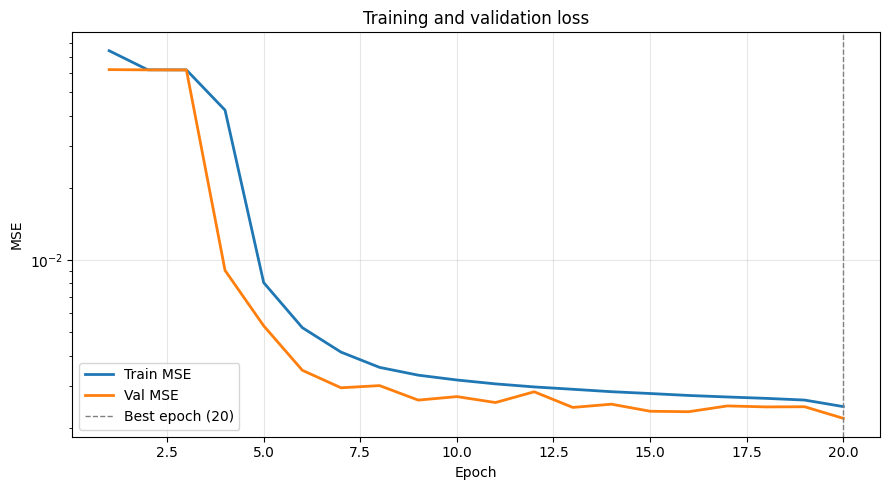

Saved: /content/drive/MyDrive/spectral-bridge/results/plots/lr_schedule.png


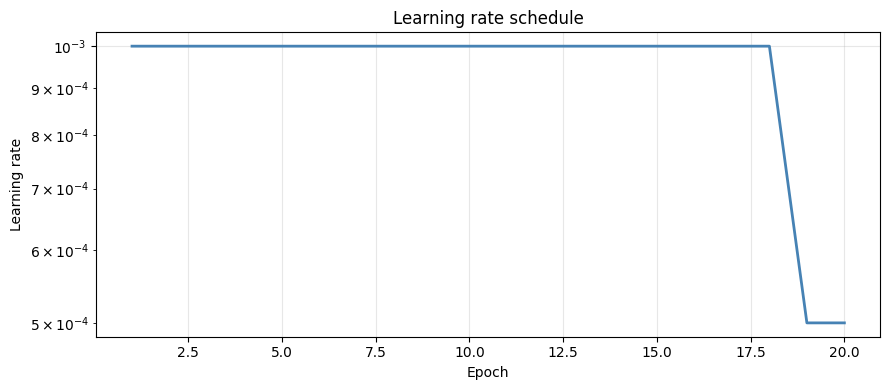


Training complete.
Best val MSE : 0.002192
Epochs run   : 20


In [ ]:
# ── Cell 6: Training ───────────────────────────────────────────────────────

from src.train import train

config.BEST_MODEL_PATH = "/content/drive/MyDrive/spectral-bridge/results/checkpoints/best_model.pth"
config.TRAIN_FILE      = TRAIN_CSV
config.PLOTS_DIR       = "/content/drive/MyDrive/spectral-bridge/results/plots"

results = train()

## Resume — model still improving at epoch 20
Loss curve shows no convergence at epoch 20 — best epoch was the final one. Resumed from checkpoint with NUM_EPOCHS=40 to allow further learning.

Device: cuda — Tesla T4
Checkpoint found — resuming training...
Resumed from epoch 20 | best val MSE so far: 0.002336


  train MSE: 0.002430 | val MSE: 0.002181 | lr: 5.00e-04
  new best — saved to best_model_best.pth
Epoch [21/40] — 32.2s


  train MSE: 0.002403 | val MSE: 0.002260 | lr: 5.00e-04
  no improvement — patience 1/5
Epoch [22/40] — 32.0s


  train MSE: 0.002385 | val MSE: 0.002379 | lr: 5.00e-04
  no improvement — patience 2/5
Epoch [23/40] — 31.6s


  train MSE: 0.002370 | val MSE: 0.002226 | lr: 2.50e-04
  no improvement — patience 3/5
Epoch [24/40] — 31.6s


...

  train MSE: 0.002257 | val MSE: 0.002071 | lr: 2.50e-04
  no improvement — patience 1/5
Epoch [28/40] — 31.7s


  train MSE: 0.002247 | val MSE: 0.002044 | lr: 2.50e-04
  no improvement — patience 2/5
Epoch [29/40] — 32.5s


  train MSE: 0.002243 | val MSE: 0.002070 | lr: 1.25e-04
  no improvement — patience 3/5
Epoch [30/40] — 32.2s


  train MSE: 0.002196 | val MSE: 0.002039 | lr: 1.25e-04
  no improvement — patience 4/5
Epoch [31/40] — 31.9s


  train MSE: 0.002192 | val MSE: 0.002102 | lr: 1.25e-04
  no improvement — patience 5/5

Early stopping at epoch 32
Epoch [32/40] — 31.6s
Saved: /content/drive/MyDrive/spectral-bridge/results/plots/loss_curve.png


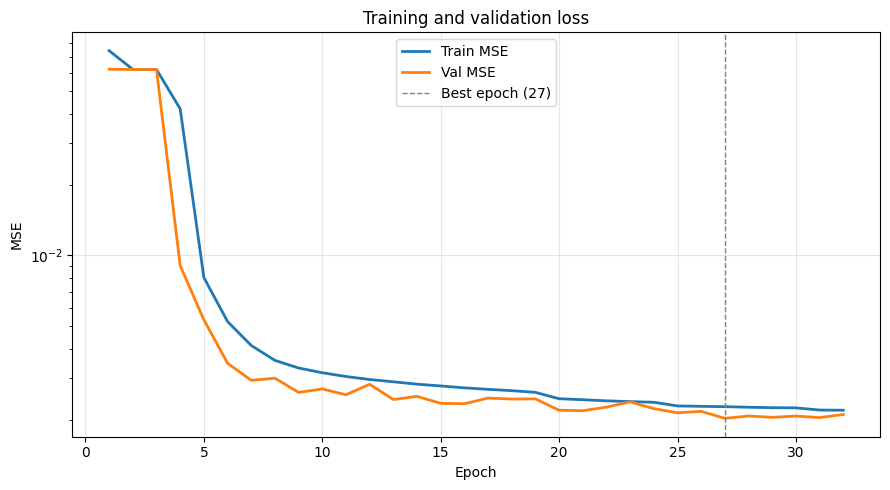

Saved: /content/drive/MyDrive/spectral-bridge/results/plots/lr_schedule.png


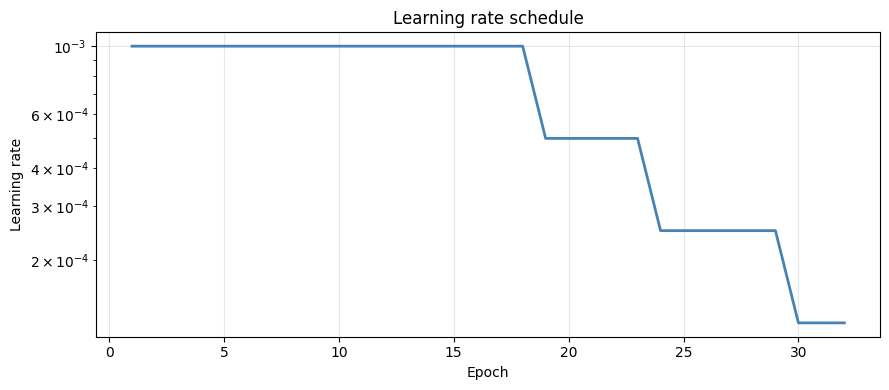


Training complete.
Best val MSE : 0.002024
Epochs run   : 32


In [ ]:
# ── Cell 6: Training (resumed) ─────────────────────────────────────────────

from src.train import train

config.BEST_MODEL_PATH = "/content/drive/MyDrive/spectral-bridge/results/checkpoints/best_model.pth"
config.TRAIN_FILE      = TRAIN_CSV
config.PLOTS_DIR       = "/content/drive/MyDrive/spectral-bridge/results/plots"
config.NUM_EPOCHS      = 40  # was 20, giving 20 more epochs

results = train()

Device: cuda — Tesla T4
Loaded best model from /content/drive/MyDrive/spectral-bridge/results/checkpoints/best_model_best.pth
SpectralTransformer(d_model=64, n_heads=4, n_layers=3, d_ff=256, dropout=0.1, params=156,609)

Final evaluation results:
  Mean MSE   : 0.002024
  Median MSE : 0.001037
  Std MSE    : 0.002908
Saved: /content/drive/MyDrive/spectral-bridge/results/plots/reconstruction.png


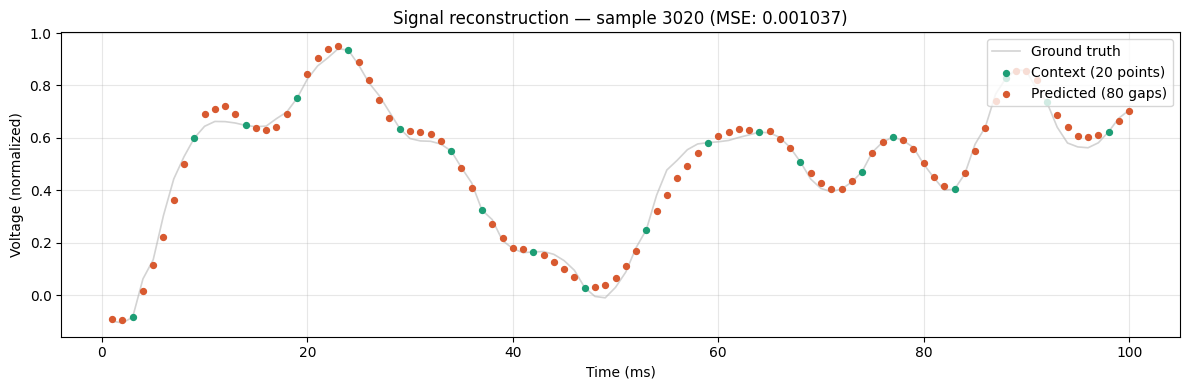

Saved: /content/drive/MyDrive/spectral-bridge/results/plots/uncertainty_bands.png


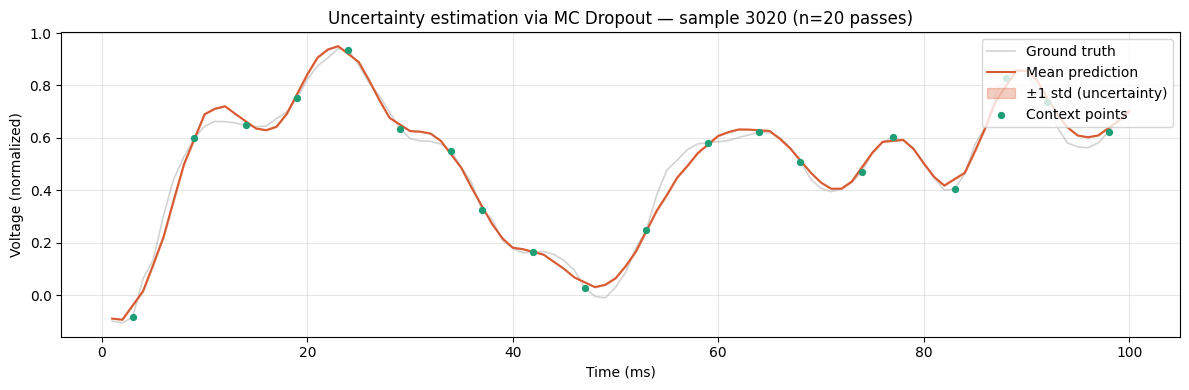

Saved: /content/drive/MyDrive/spectral-bridge/results/plots/multi_instrument_grid.png


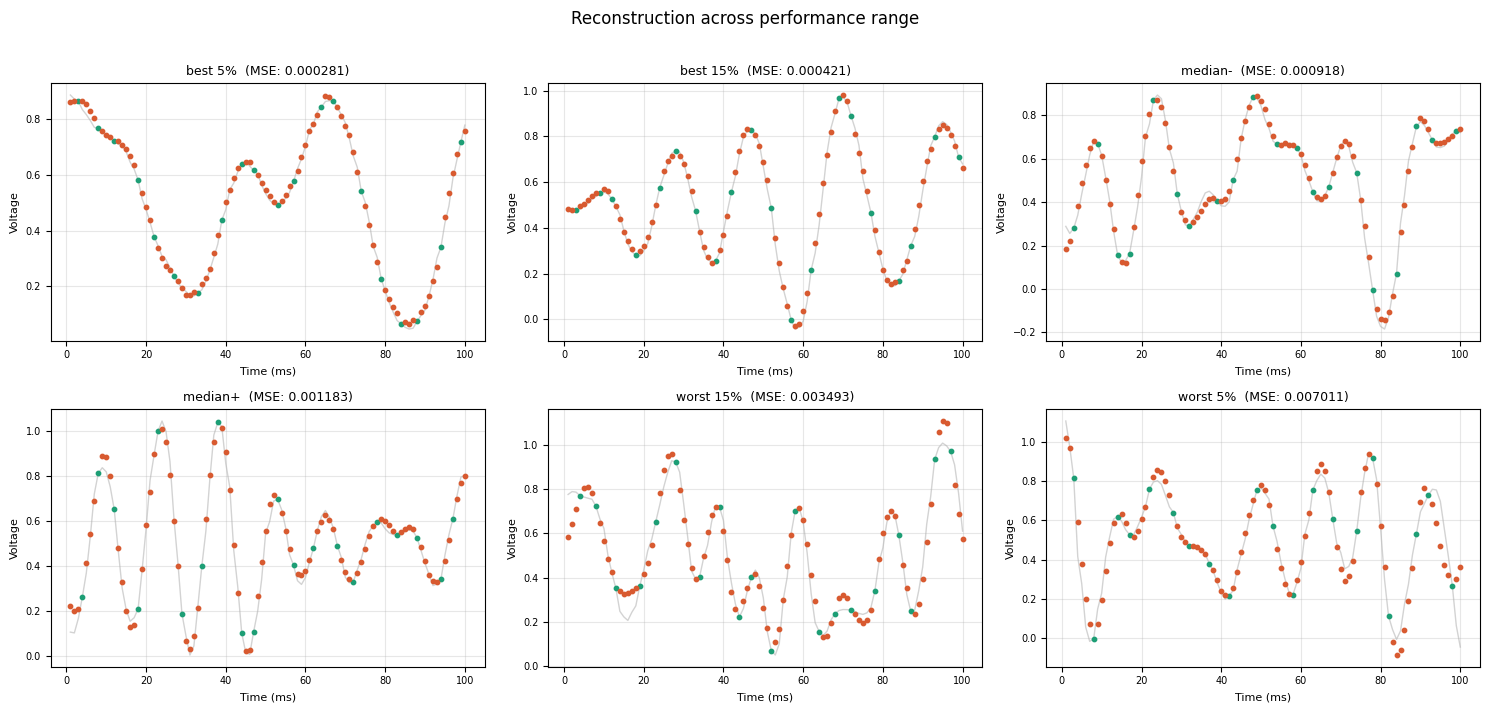

Saved: /content/drive/MyDrive/spectral-bridge/results/plots/residual_distribution.png


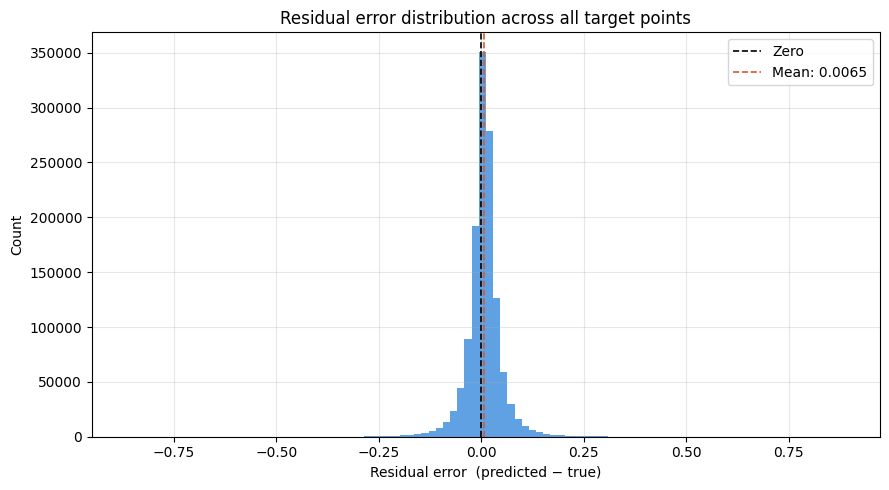

Saved: /content/drive/MyDrive/spectral-bridge/results/plots/mse_distribution.png


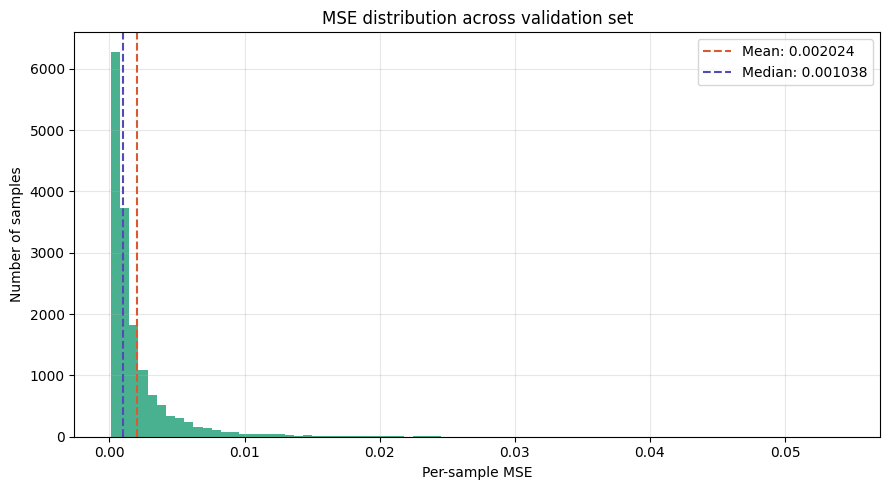

Saved: /content/drive/MyDrive/spectral-bridge/results/plots/predicted_vs_actual.png


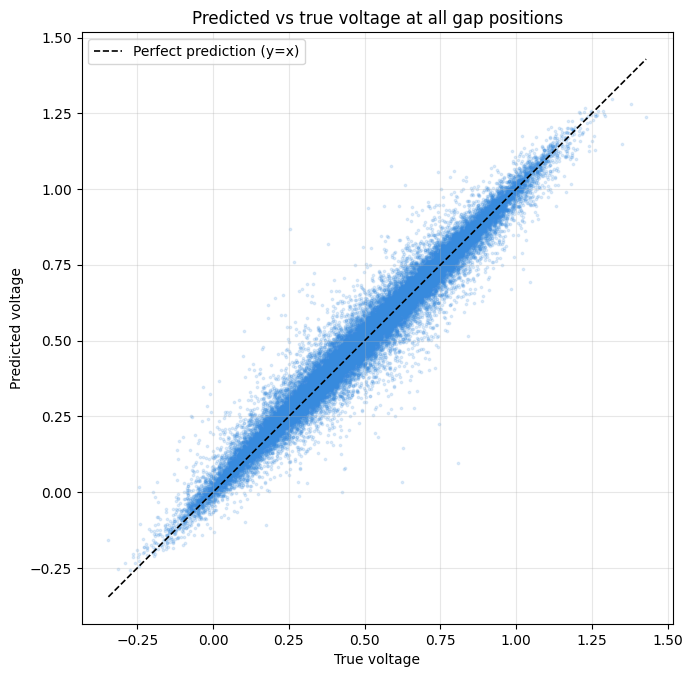

In [7]:
# ── Cell 7: Full diagnostic evaluation via evaluate.py ────────────────────

from src.evaluate import evaluate

config.BEST_MODEL_PATH = "/content/drive/MyDrive/spectral-bridge/results/checkpoints/best_model.pth"
config.TRAIN_FILE      = TRAIN_CSV
config.PLOTS_DIR       = "/content/drive/MyDrive/spectral-bridge/results/plots"

metrics = evaluate(csv_path=TRAIN_CSV)

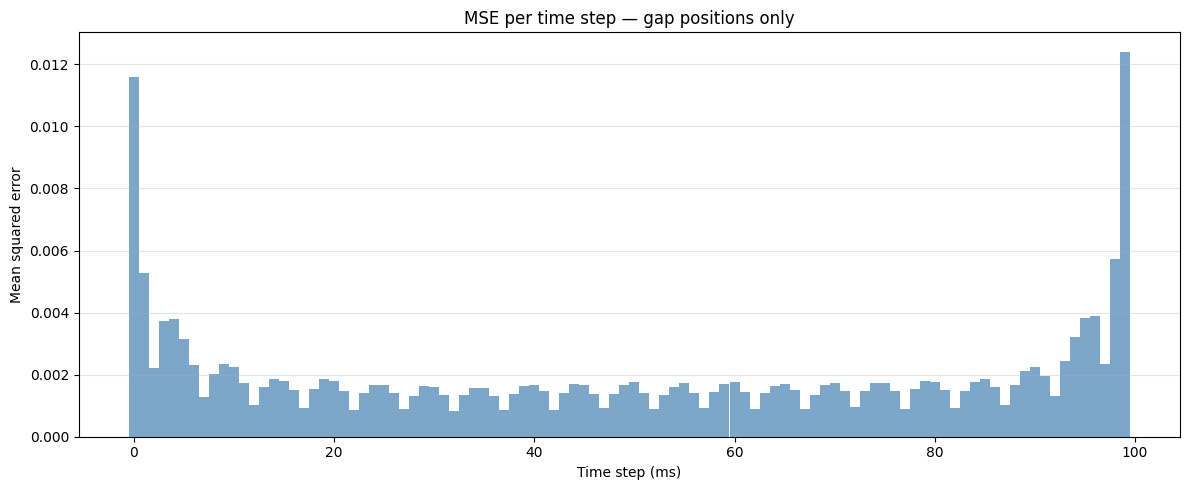

Easiest position : t=32ms  MSE=0.000819
Hardest position : t=99ms  MSE=0.012411


In [8]:
# ── Cell 8: MSE per time step ─────────────────────────────────────────

position_errors = np.zeros(config.SEQ_LEN)
position_counts = np.zeros(config.SEQ_LEN)

model.eval()
with torch.no_grad():
    for batch in val_loader:
        x      = batch["x"].to(device)
        y_true = batch["y_true"].to(device)
        mask   = batch["mask"].to(device)
        y_pred = model(x)

        errors = (y_pred.cpu().numpy() - y_true.cpu().numpy()) ** 2
        mask_np = mask.cpu().numpy()

        for t in range(config.SEQ_LEN):
            gap_samples = mask_np[:, t] == 0
            if gap_samples.any():
                position_errors[t] += errors[gap_samples, t].sum()
                position_counts[t] += gap_samples.sum()

position_mse = np.divide(
    position_errors, position_counts,
    out=np.zeros_like(position_errors),
    where=position_counts > 0
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(np.arange(config.SEQ_LEN), position_mse,
       color="steelblue", alpha=0.7, width=1.0)
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Mean squared error")
ax.set_title("MSE per time step — gap positions only")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/spectral-bridge/results/plots/mse_per_position.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Easiest position : t={position_mse[position_mse>0].argmin()}ms  "
      f"MSE={position_mse[position_mse>0].min():.6f}")
print(f"Hardest position : t={position_mse.argmax()}ms  "
      f"MSE={position_mse.max():.6f}")

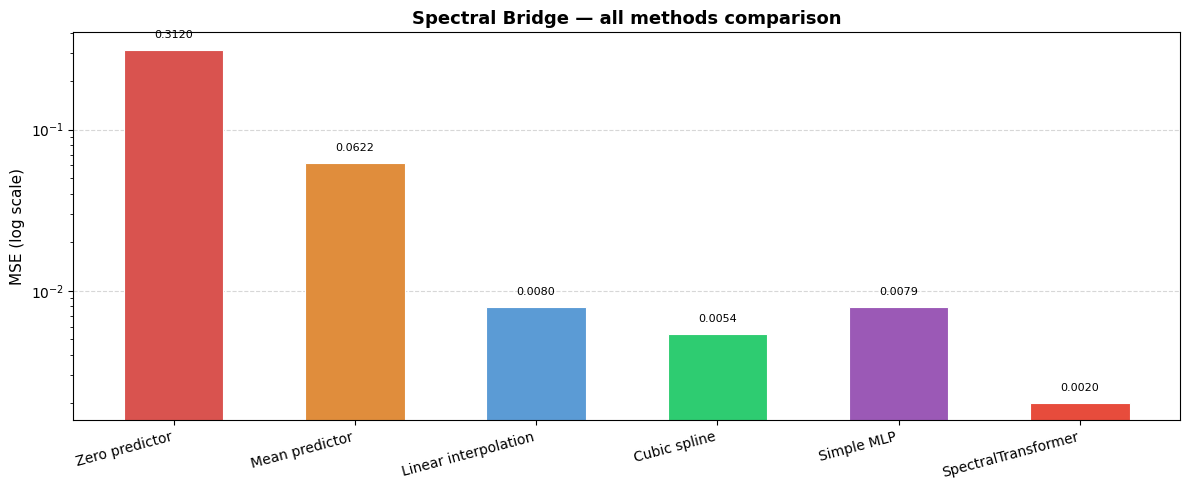

  SPECTRAL BRIDGE — Final Results
  Method                           MSE   vs Zero
-------------------------------------------------------
  Zero predictor              0.311986      1.0×
  Mean predictor              0.062171      5.0×
  Linear interpolation        0.007958     39.2×
  Cubic spline                0.005403     57.7×
  Simple MLP                  0.007928     39.4×
  SpectralTransformer         0.002024    154.1× ◄

  Transformer beats cubic spline by 2.67×


In [9]:
# ── Cell 9: Summary — comparison against all baselines ───────────────────

baselines = {
    "Zero predictor":       0.311986,
    "Mean predictor":       0.062171,
    "Linear interpolation": 0.007958,
    "Cubic spline":         0.005403,
    "Simple MLP":           0.007928,
    "SpectralTransformer":  0.002024,
}

names  = list(baselines.keys())
mses   = list(baselines.values())
colors = ["#d9534f", "#e08d3c", "#5b9bd5", "#2ecc71", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, mses, color=colors, width=0.55,
              edgecolor="white", linewidth=0.8)
ax.set_yscale("log")
ax.set_ylabel("MSE (log scale)", fontsize=11)
ax.set_title("Spectral Bridge — all methods comparison", fontsize=13, fontweight="bold")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, mses):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=8
    )

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/spectral-bridge/results/plots/final_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("=" * 55)
print("  SPECTRAL BRIDGE — Final Results")
print("=" * 55)
print(f"  {'Method':<25} {'MSE':>10}  {'vs Zero':>8}")
print("-" * 55)
zero_mse = baselines["Zero predictor"]
for name, mse in baselines.items():
    marker = " ◄" if name == "SpectralTransformer" else ""
    print(f"  {name:<25} {mse:>10.6f}  {zero_mse/mse:>7.1f}×{marker}")
print("=" * 55)
print(f"\n  Transformer beats cubic spline by "
      f"{baselines['Cubic spline'] / baselines['SpectralTransformer']:.2f}×")